# Production-Grade Prompt Versioning with LangGraph

## Folder structure
```
prompts_prod/
  support_v1.json   ← stable · plain text · all channels
  support_v2.json   ← stable · JSON output · CRM/ticketing
  support_v3.json   ← beta   · expert CoT  · Tier 2 only
```

## What each JSON file contains
| Section | Fields |
|---|---|
| `metadata` | version, status, environment, author, tags |
| `model` | name, temperature, max_tokens, penalties |
| `prompt` | system prompt + user_template with `{placeholders}` |
| `few_shot_examples` | worked examples injected before user message |
| `output_rules` | format, forbidden phrases, required fields, tone check |
| `channels` | where this version is allowed to run |
| `fallback_version` | which version to use if this one fails |

## LangGraph pipeline
```
user_input + version + channel
  → load_prompt      (read + schema-validate JSON)
  → build_messages   (system + few-shot + rendered user template)
  → call_llm         (model settings from JSON)
  → validate_output  (format + tone + required fields)
  → log_and_return   (audit log entry)
  OR fallback        (load v1 safe prompt on failure)
```

In [1]:
from typing import TypedDict, Optional, Literal
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from IPython.display import Image, display
from dotenv import load_dotenv
from datetime import datetime
import json, os, time

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

PROMPTS_DIR = "prompts_prod"

In [2]:
# ── State ─────────────────────────────────────────────────
class SupportState(TypedDict):
    # Inputs
    version:        str           # e.g. "support_v2"
    channel:        str           # e.g. "api", "chat", "email"
    user_vars:      dict          # Template variables for user_template

    # Pipeline data
    prompt_config:  Optional[dict]     # Full loaded JSON
    messages:       Optional[list]     # Built message list
    raw_response:   Optional[str]      # LLM raw output
    parsed_response:Optional[dict]     # Parsed if JSON format
    validation_ok:  Optional[bool]     # Did output pass rules?
    validation_errors: Optional[list]  # List of issues found
    used_fallback:  Optional[bool]     # Did we fall back to v1?

    # Audit log
    audit_log:      Optional[dict]     # Metadata for logging

load_prompt (Load and validate prompt configuration)

Purpose

Read the versioned prompt JSON file, validate its schema, and check that the requested channel is allowed for this version.

How it works

Builds the file path: prompts_prod/{version}.json.

Loads the JSON and checks for required top‑level keys: metadata, model, prompt, output_rules.

Verifies that the channel is in the channels list of the config (prevents a beta version from being served on chat).

Stores the full config in prompt_config.

Output

State with prompt_config populated.

In [3]:
# ── Node 1: load_prompt ───────────────────────────────────
# Reads the JSON file, validates required sections exist,
# and checks the version is allowed on the requested channel.

def load_prompt(state: SupportState) -> SupportState:
    version  = state["version"]
    channel  = state["channel"]
    filepath = os.path.join(PROMPTS_DIR, f"{version}.json")

    print(f"\n[load_prompt] Loading: {filepath}")

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Prompt not found: {filepath}")

    with open(filepath) as f:
        config = json.load(f)

    # Schema validation — required top-level keys
    required_keys = ["metadata", "model", "prompt", "output_rules"]
    missing = [k for k in required_keys if k not in config]
    if missing:
        raise ValueError(f"Prompt JSON missing required keys: {missing}")

    # Channel check — is this version allowed on this channel?
    allowed_channels = config.get("channels", [])
    if channel not in allowed_channels:
        raise ValueError(
            f"Version '{version}' is not allowed on channel '{channel}'. "
            f"Allowed: {allowed_channels}"
        )

    meta = config["metadata"]
    print(f"  version     : {meta['version']}")
    print(f"  name        : {meta['name']}")
    print(f"  status      : {meta['status']}")
    print(f"  channel ok  : {channel}")

    return {**state, "prompt_config": config}

build_messages (Assemble message list)

Purpose

Construct the full message list sent to the LLM: system prompt, few‑shot examples, and the rendered user template.

How it works

Starts with a SystemMessage from prompt.prompt.system.

Iterates over few_shot_examples (each has role and content).

role: "user" → HumanMessage

role: "assistant" → AIMessage

Renders the user_template using user_vars (e.g., "{customer_name}" replaced). If a variable is missing, raises a clear error.

Appends the rendered user message as a HumanMessage.

Stores the list as dictionaries (for serialisation).

Output

State with messages list.

In [4]:
# ── Node 2: build_messages ────────────────────────────────
# Assembles the full message list:
#   1. SystemMessage  — from prompt.system
#   2. Few-shot pairs — HumanMessage + AIMessage for each example
#   3. HumanMessage   — user_template with variables filled in

def build_messages(state: SupportState) -> SupportState:
    config   = state["prompt_config"]
    user_vars = state["user_vars"]

    print(f"[build_messages] Assembling message list...")

    # 1. System prompt
    messages = [SystemMessage(content=config["prompt"]["system"])]

    # 2. Few-shot examples (HumanMessage / AIMessage alternating)
    examples = config.get("few_shot_examples", [])
    for ex in examples:
        if ex["role"] == "user":
            messages.append(HumanMessage(content=ex["content"]))
        elif ex["role"] == "assistant":
            messages.append(AIMessage(content=ex["content"]))

    # 3. Render user template — fill in {placeholders}
    template = config["prompt"].get("user_template", "{user_message}")
    try:
        rendered = template.format(**user_vars)
    except KeyError as e:
        raise ValueError(f"Missing template variable: {e}. "
                         f"Template needs: {template}")

    messages.append(HumanMessage(content=rendered))

    print(f"  system + {len(examples)} few-shot + 1 user = {len(messages)} messages")
    return {**state, "messages": [m.dict() for m in messages]}

call_llm (Invoke the language model)

Purpose

Create an LLM instance using the model settings from the prompt config and generate a response.

How it works

Reads model section from prompt_config (name, temperature, max_tokens, top_p, penalties).

Initialises ChatOpenAI with those parameters.

Reconstructs LangChain message objects from the stored dictionaries.

Calls the LLM and measures elapsed time.

Stores the raw output in raw_response.

Output

State with raw_response.

In [5]:
# ── Node 3: call_llm ──────────────────────────────────────
# Configures the LLM from the JSON model settings and calls it.
# All LLM parameters come from the prompt file — not hardcoded.

def call_llm(state: SupportState) -> SupportState:
    config     = state["prompt_config"]
    model_cfg  = config["model"]

    llm = ChatOpenAI(
        model               = model_cfg["name"],
        temperature         = model_cfg["temperature"],
        max_tokens          = model_cfg["max_tokens"],
        top_p               = model_cfg.get("top_p", 1.0),
        presence_penalty    = model_cfg.get("presence_penalty", 0.0),
        frequency_penalty   = model_cfg.get("frequency_penalty", 0.0),
    )

    print(f"[call_llm] Model: {model_cfg['name']} | "
          f"temp={model_cfg['temperature']} | "
          f"max_tokens={model_cfg['max_tokens']}")

    # Reconstruct message objects from stored dicts
    raw_messages = []
    for m in state["messages"]:
        if m["type"] == "system":
            raw_messages.append(SystemMessage(content=m["content"]))
        elif m["type"] == "human":
            raw_messages.append(HumanMessage(content=m["content"]))
        elif m["type"] == "ai":
            raw_messages.append(AIMessage(content=m["content"]))

    t0 = time.time()
    response = llm.invoke(raw_messages)
    elapsed  = round(time.time() - t0, 2)

    print(f"[call_llm] Response received in {elapsed}s")
    return {**state, "raw_response": response.content.strip()}

validate_output (Enforce output rules)

Purpose

Check the LLM’s response against the output_rules defined in the prompt config. This is the contract between the prompt version and the system.

How it works

If format == "json":

Strips potential markdown fences (```json).

Parses JSON.

Checks that all required_fields exist (supports dot notation, e.g., response.greeting).

Checks forbidden_phrases (case‑insensitive) in the raw response.

If format == "plain_text" and a required_ending is specified, ensures it appears.

Checks max_length_chars (if set).

Sets validation_ok (True if no errors) and validation_errors (list of error strings).

Output

State with validation_ok, validation_errors, and parsed_response (if JSON).

In [6]:
# ── Node 4: validate_output ───────────────────────────────
# Checks the LLM output against the output_rules in the JSON:
#   - If format=json: tries to parse, checks required fields
#   - Checks for forbidden phrases
#   - Checks required ending (for plain text)
#   - Checks character length

def validate_output(state: SupportState) -> SupportState:
    rules   = state["prompt_config"]["output_rules"]
    raw     = state["raw_response"]
    errors  = []
    parsed  = None

    print(f"[validate_output] Checking output against rules...")

    # JSON format validation
    if rules.get("format") == "json":
        try:
            clean = raw.strip().lstrip("```json").rstrip("```").strip()
            parsed = json.loads(clean)

            # Check required fields
            required_fields = rules.get("required_fields", [])
            for field in required_fields:
                # Support dot-notation: response.greeting
                parts = field.split(".")
                obj = parsed
                for part in parts:
                    if isinstance(obj, dict) and part in obj:
                        obj = obj[part]
                    else:
                        errors.append(f"Missing required field: {field}")
                        break

        except json.JSONDecodeError as e:
            errors.append(f"Invalid JSON output: {e}")

    # Forbidden phrases check (applies to all formats)
    for phrase in rules.get("forbidden_phrases", []):
        if phrase.lower() in raw.lower():
            errors.append(f"Forbidden phrase detected: '{phrase}'")

    # Required ending check (plain text)
    if rules.get("format") == "plain_text":
        required_ending = rules.get("required_ending")
        if required_ending and required_ending not in raw:
            errors.append(f"Missing required ending: '{required_ending}'")

    # Length check
    max_len = rules.get("max_length_chars")
    if max_len and len(raw) > max_len:
        errors.append(f"Response too long: {len(raw)} chars > {max_len} limit")

    is_valid = len(errors) == 0
    if is_valid:
        print(f"[validate_output] All checks passed")
    else:
        print(f"[validate_output] {len(errors)} error(s): {errors}")

    return {
        **state,
        "parsed_response":  parsed,
        "validation_ok":    is_valid,
        "validation_errors":errors
    }

log_and_return (Success audit)

Purpose

Record a successful execution in the audit log and finish.

How it works

Creates a log dictionary with:

timestamp, version, prompt_name, channel, model,

validation_ok, used_fallback, customer, output_format, response_chars.

Stores it in audit_log.

Output

State with audit_log; graph ends.

fallback (Failure recovery)

Purpose

When validation fails, load a safer prompt version (usually support_v1) and generate a response, marking that a fallback was used.

How it works

Reads fallback_version from the original prompt config (default "support_v1").

Loads the fallback JSON file.

Renders its user_template safely – only passes variables that actually appear in the template (avoids KeyError).

Calls the LLM with the fallback system prompt and rendered user message.

Sets used_fallback = True.

Stores the response in raw_response and creates an audit log entry that includes original_errors.

Output

State with raw_response, used_fallback, and audit_log.



In [7]:
# ── Node 5a: log_and_return ───────────────────────────────
# On success: writes an audit log entry and returns.

def log_and_return(state: SupportState) -> SupportState:
    config = state["prompt_config"]
    log = {
        "timestamp":       datetime.utcnow().isoformat(),
        "version":         config["metadata"]["version"],
        "prompt_name":     config["metadata"]["name"],
        "channel":         state["channel"],
        "model":           config["model"]["name"],
        "validation_ok":   state["validation_ok"],
        "used_fallback":   state.get("used_fallback", False),
        "customer":        state["user_vars"].get("customer_name", "unknown"),
        "output_format":   config["output_rules"]["format"],
        "response_chars":  len(state["raw_response"]),
    }
    print(f"[log_and_return] Audit log entry written")
    return {**state, "audit_log": log}


# ── Node 5b: fallback ─────────────────────────────────────
# On failure: loads the fallback version from the JSON config,
# or defaults to support_v1. Runs a simple safe response.

def fallback(state: SupportState) -> SupportState:
    config           = state["prompt_config"]
    fallback_version = config.get("fallback_version", "support_v1")
    fallback_path    = os.path.join(PROMPTS_DIR, f"{fallback_version}.json")

    print(f"[fallback] Validation failed — loading fallback: {fallback_version}")
    print(f"  Errors: {state['validation_errors']}")

    with open(fallback_path) as f:
        fb_config = json.load(f)

    llm = ChatOpenAI(
        model       = fb_config["model"]["name"],
        temperature = fb_config["model"]["temperature"],
        max_tokens  = fb_config["model"]["max_tokens"],
    )

    # Render fallback user template
    template = fb_config["prompt"].get("user_template", "{user_message}")
    # Only pass variables the fallback template needs
    safe_vars = {k: v for k, v in state["user_vars"].items()
                 if f"{{{k}}}" in template}
    rendered  = template.format_map({**state["user_vars"], **safe_vars})

    messages = [
        SystemMessage(content=fb_config["prompt"]["system"]),
        HumanMessage(content=rendered)
    ]

    response = llm.invoke(messages)
    log = {
        "timestamp":      datetime.utcnow().isoformat(),
        "version":        "fallback:" + fallback_version,
        "prompt_name":    fb_config["metadata"]["name"],
        "channel":        state["channel"],
        "model":          fb_config["model"]["name"],
        "validation_ok":  True,
        "used_fallback":  True,
        "original_errors":state["validation_errors"],
    }
    return {
        **state,
        "raw_response":   response.content.strip(),
        "parsed_response":None,
        "used_fallback":  True,
        "audit_log":      log
    }

Routing: route_after_validation

Purpose

Decide whether to return the successful response or trigger a fallback.

Logic

If validation_ok == True → return "log_and_return".

Else → return "fallback".



In [8]:
# ── Router ────────────────────────────────────────────────
def route_after_validation(
    state: SupportState
) -> Literal["log_and_return", "fallback"]:
    if state["validation_ok"]:
        return "log_and_return"
    return "fallback"

START → load_prompt → build_messages → call_llm → validate_output
                                                      ↓ (conditional)
                                            ┌─────────┴─────────┐
                                            ↓                   ↓
                                     log_and_return         fallback
                                            ↓                   ↓
                                           END                  END

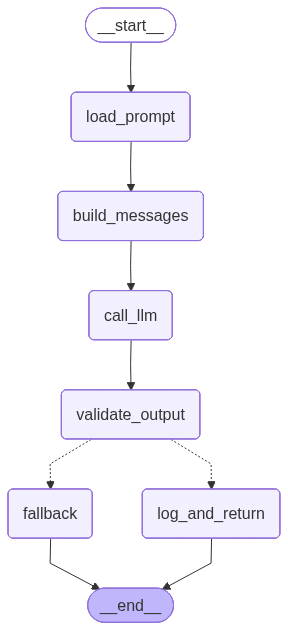

In [9]:
# ── Graph Construction ─────────────────────────────────────
def build_graph():
    builder = StateGraph(SupportState)

    builder.add_node("load_prompt",      load_prompt)
    builder.add_node("build_messages",   build_messages)
    builder.add_node("call_llm",         call_llm)
    builder.add_node("validate_output",  validate_output)
    builder.add_node("log_and_return",   log_and_return)
    builder.add_node("fallback",         fallback)

    builder.add_edge(START,              "load_prompt")
    builder.add_edge("load_prompt",      "build_messages")
    builder.add_edge("build_messages",   "call_llm")
    builder.add_edge("call_llm",         "validate_output")
    builder.add_conditional_edges(
        "validate_output",
        route_after_validation,
        {"log_and_return": "log_and_return", "fallback": "fallback"}
    )
    builder.add_edge("log_and_return",   END)
    builder.add_edge("fallback",         END)

    return builder.compile()


graph = build_graph()
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
# ── Helper ────────────────────────────────────────────────
def run(version: str, channel: str, user_vars: dict) -> dict:
    return graph.invoke({
        "version":          version,
        "channel":          channel,
        "user_vars":        user_vars,
        "prompt_config":    None,
        "messages":         None,
        "raw_response":     None,
        "parsed_response":  None,
        "validation_ok":    None,
        "validation_errors":None,
        "used_fallback":    False,
        "audit_log":        None,
    })

In [11]:
# ── Test 1: v1 plain text via chat channel ────────────────
r1 = run(
    version = "support_v1",
    channel = "chat",
    user_vars = {
        "customer_name": "Anil",
        "plan":          "Pro",
        "user_message":  "My dashboard won't load since this morning."
    }
)
print("\nRESPONSE:")
print(r1["raw_response"])
print("\nAUDIT LOG:")
print(json.dumps(r1["audit_log"], indent=2))


[load_prompt] Loading: prompts_prod\support_v1.json
  version     : v1.2.0
  name        : support_conservative
  status      : stable
  channel ok  : chat
[build_messages] Assembling message list...
  system + 2 few-shot + 1 user = 4 messages


C:\Users\anilk\AppData\Local\Temp\ipykernel_34428\706787021.py:35: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  return {**state, "messages": [m.dict() for m in messages]}


[call_llm] Model: gpt-4o | temp=0.1 | max_tokens=300
[call_llm] Response received in 2.67s
[validate_output] Checking output against rules...
[validate_output] All checks passed
[log_and_return] Audit log entry written

RESPONSE:
Hi Anil, I understand how frustrating it can be when your dashboard won't load. Please try clearing your browser cache and refreshing the page. If the problem continues, let me connect you with our specialist team to look into this further. Is there anything else I can help you with?

AUDIT LOG:
{
  "timestamp": "2026-04-03T10:39:47.198560",
  "version": "v1.2.0",
  "prompt_name": "support_conservative",
  "channel": "chat",
  "model": "gpt-4o",
  "validation_ok": true,
  "used_fallback": false,
  "customer": "Anil",
  "output_format": "plain_text",
  "response_chars": 284
}


C:\Users\anilk\AppData\Local\Temp\ipykernel_34428\2542011963.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp":       datetime.utcnow().isoformat(),


In [12]:
# ── Test 2: v2 JSON output via API ────────────────────────
r2 = run(
    version = "support_v2",
    channel = "api",
    user_vars = {
        "customer_name":   "Priya",
        "plan":            "Enterprise",
        "account_age_days":"420",
        "open_tickets":    "0",
        "user_message":    "We are being charged for 50 seats but only have 30 active users."
    }
)
print("\nPARSED JSON RESPONSE:")
print(json.dumps(r2["parsed_response"], indent=2))
print(f"\nUsed fallback: {r2['used_fallback']}")


[load_prompt] Loading: prompts_prod\support_v2.json
  version     : v2.1.0
  name        : support_detailed
  status      : stable
  channel ok  : api
[build_messages] Assembling message list...
  system + 2 few-shot + 1 user = 4 messages
[call_llm] Model: gpt-4o | temp=0.2 | max_tokens=800


C:\Users\anilk\AppData\Local\Temp\ipykernel_34428\706787021.py:35: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  return {**state, "messages": [m.dict() for m in messages]}


[call_llm] Response received in 7.14s
[validate_output] Checking output against rules...
[validate_output] All checks passed
[log_and_return] Audit log entry written

PARSED JSON RESPONSE:
{
  "greeting": "Hi Priya",
  "issue_summary": "Customer is billed for 50 seats but only has 30 active users.",
  "category": "billing",
  "priority": "high",
  "response": "Hi Priya, thank you for bringing this billing issue to our attention. I understand how important it is to ensure accurate billing, especially on an Enterprise plan. We will review your account and adjust the charges accordingly to reflect the correct number of active users.",
  "action_items": [
    "Review the account for active user count",
    "Adjust billing to reflect the correct number of seats"
  ],
  "escalate": true,
  "escalation_reason": "Billing discrepancy requires finance team intervention",
  "suggested_article": "How to manage team seats and billing",
  "closing": "Is there anything else I can help you with?"
}

U

C:\Users\anilk\AppData\Local\Temp\ipykernel_34428\2542011963.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp":       datetime.utcnow().isoformat(),


In [13]:
# ── Test 3: v3 expert CoT via API ─────────────────────────
r3 = run(
    version = "support_v3",
    channel = "api",
    user_vars = {
        "customer_name": "Dev Team at Acme",
        "plan":          "Enterprise",
        "account_id":    "ACM-00291",
        "region":        "ap-south-1",
        "browser_os":    "Chrome 122 / Windows 11",
        "error_message": "503 Service Unavailable on /api/v2/webhooks",
        "steps_tried":   "Checked API key, retried after 10 min",
        "user_message":  "Our webhook integration has been broken for 2 hours. Production is affected."
    }
)
print("\nREASONING:")
if r3["parsed_response"]:
    print(json.dumps(r3["parsed_response"]["reasoning"], indent=2))
    print("\nRESPONSE TO CUSTOMER:")
    print(json.dumps(r3["parsed_response"]["response"], indent=2))
    print("\nMETADATA:")
    print(json.dumps(r3["parsed_response"]["metadata"], indent=2))


[load_prompt] Loading: prompts_prod\support_v3.json
  version     : v3.0.1
  name        : support_expert_technical
  status      : beta
  channel ok  : api
[build_messages] Assembling message list...
  system + 2 few-shot + 1 user = 4 messages
[call_llm] Model: gpt-4o | temp=0.0 | max_tokens=1200


C:\Users\anilk\AppData\Local\Temp\ipykernel_34428\706787021.py:35: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  return {**state, "messages": [m.dict() for m in messages]}


[call_llm] Response received in 2.99s
[validate_output] Checking output against rules...
[validate_output] All checks passed
[log_and_return] Audit log entry written

REASONING:
{
  "possible_causes": [
    "Regional infrastructure degradation in ap-south-1",
    "Rate limit breach on webhook endpoint",
    "Expired or rotated API credentials",
    "Webhook endpoint schema change in recent deployment"
  ],
  "most_likely_cause": "Regional infrastructure degradation in ap-south-1 \u00e2\u20ac\u201d 503 errors at infrastructure level, not application level",
  "confidence": "high",
  "known_issue": true,
  "known_issue_reference": "INC-20291-AP-SOUTH"
}

RESPONSE TO CUSTOMER:
{
  "greeting": "Hi Acme Dev Team",
  "diagnosis": "We are seeing a known infrastructure incident in the ap-south-1 region affecting webhook delivery (INC-20291-AP-SOUTH).",
  "steps": [
    "Check our status page at status.cloudbase.io for live incident updates",
    "Temporarily route webhook traffic to us-east-1 

C:\Users\anilk\AppData\Local\Temp\ipykernel_34428\2542011963.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp":       datetime.utcnow().isoformat(),


In [14]:
# ── Test 4: Channel mismatch (should raise) ───────────────
try:
    run(
        version   = "support_v3",
        channel   = "chat",        # v3 only allows api + internal_tools
        user_vars = {"customer_name": "test", "plan": "Pro",
                     "account_id": "X", "region": "us",
                     "browser_os": "Chrome", "error_message": "none",
                     "steps_tried": "none", "user_message": "hello"}
    )
except ValueError as e:
    print(f"Expected error: {e}")


[load_prompt] Loading: prompts_prod\support_v3.json
Expected error: Version 'support_v3' is not allowed on channel 'chat'. Allowed: ['api', 'internal_tools']


In [15]:
# ── List all available prompt versions ────────────────────
print("AVAILABLE PROMPT VERSIONS")
print("-" * 50)
for fname in sorted(os.listdir(PROMPTS_DIR)):
    if fname.endswith(".json"):
        with open(os.path.join(PROMPTS_DIR, fname)) as f:
            d = json.load(f)
        m = d["metadata"]
        print(f"{fname:25} v{m['version']:10} [{m['status']:8}] "
              f"channels={d['channels']}")

AVAILABLE PROMPT VERSIONS
--------------------------------------------------
support_v1.json           vv1.2.0     [stable  ] channels=['email', 'chat', 'in_app']
support_v2.json           vv2.1.0     [stable  ] channels=['api', 'crm', 'ticketing_system']
support_v3.json           vv3.0.1     [beta    ] channels=['api', 'internal_tools']


## Production JSON schema — field-by-field

### `metadata`
Tracks lineage — who wrote it, when, what status it's in, which environments it can run on.

### `model`
All LLM settings in one place. Changing temperature or max_tokens = edit JSON, no code change.

### `prompt.system` + `prompt.user_template`
The system prompt is fixed. The user template uses `{placeholders}` filled at runtime by `user_vars`. Missing variables raise a clear error.

### `few_shot_examples`
List of `{role, content}` pairs. Injected between system and user message. Teaches the model the exact output format without repeating it in the system prompt.

### `output_rules`
Runtime contract — what a valid response looks like. The `validate_output` node enforces this automatically.

### `channels`
Prevents a verbose API-only prompt (v3) accidentally being served to end-users via chat.

### `fallback_version`
If validation fails, the graph automatically loads this safer version instead of returning an error to the user.

## How to add a new version
1. Copy an existing JSON file: `cp prompts_prod/support_v2.json prompts_prod/support_v4.json`
2. Edit `metadata.version`, `metadata.name`, the system prompt, and output rules
3. Call `run("support_v4", "api", {...})` — no code changes needed